# Stock Price Predictor
**Internship Project — Codec Technologies (AI Internship)**

Goal: predict future stock closing prices using historical price data.

Dataset: live historical data pulled directly via the `yfinance` library — no manual download needed.

## 1. Setup — install & import libraries

In [1]:
!pip install -q yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Download historical stock data

In [2]:
TICKER = 'AAPL'  # change to any stock symbol, e.g. 'TCS.NS', 'INFY.NS', 'GOOGL'

df = yf.download(TICKER, start='2018-01-01', end='2024-12-31')
df = df[['Close']].reset_index()
print(df.shape)
df.head()

/tmp/ipykernel_536/3713329665.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start='2018-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed

(1760, 2)


Price,Date,Close
Ticker,,AAPL
0,2018-01-02,40.232380
1,2018-01-03,40.225365
2,2018-01-04,40.412216
3,2018-01-05,40.872322
4,2018-01-08,40.720520


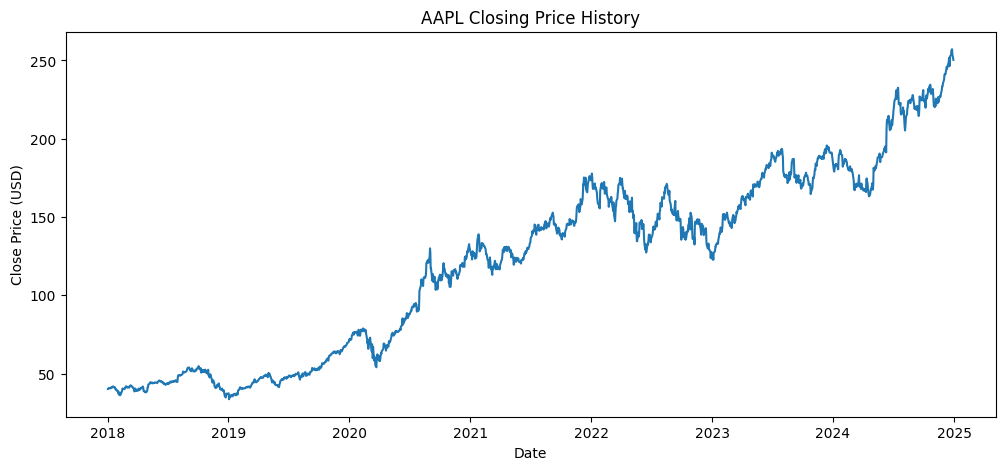

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title(f'{TICKER} Closing Price History')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.show()

## 3. Feature engineering
Use the past N days' closing prices as features to predict the next day's close.

In [4]:
WINDOW = 5  # use last 5 days to predict the next day

data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

X, y = [], []
for i in range(WINDOW, len(scaled_data)):
    X.append(scaled_data[i-WINDOW:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
print('X shape:', X.shape, ' y shape:', y.shape)

X shape: (1755, 5)  y shape: (1755,)


## 4. Train/test split & model training
(Time-series data — split chronologically, not randomly, so the model never sees the future.)

In [5]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 5. Evaluate the model

In [6]:
# inverse-transform back to real price scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1,1))

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.4f}')

MAE:  2.00
RMSE: 2.69
R2:   0.9881


## 6. Plot predicted vs actual prices

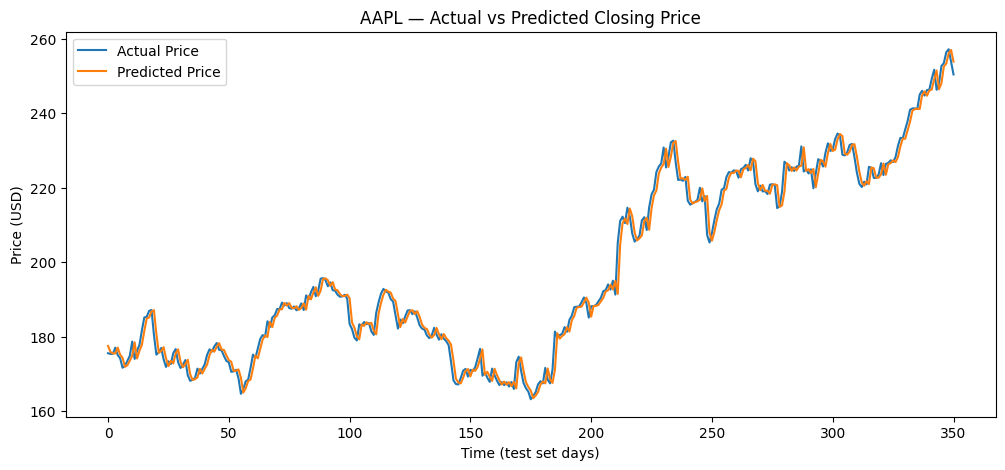

In [7]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred_actual, label='Predicted Price')
plt.title(f'{TICKER} — Actual vs Predicted Closing Price')
plt.xlabel('Time (test set days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 7. Predict the next day's closing price

In [8]:
last_window = scaled_data[-WINDOW:].reshape(1, -1)
next_day_scaled = model.predict(last_window)
next_day_price = scaler.inverse_transform(next_day_scaled.reshape(-1,1))

print(f'Predicted next closing price for {TICKER}: ${next_day_price[0][0]:.2f}')

Predicted next closing price for AAPL: $250.62
